In [1]:
"""Project Overview
Business Objective:
To ensure there is no discrimination between employees, Company X seeks to
automate salary decisions by using historical hiring data. The aim is to build a
 model that predicts the salary to be offered to a candidate based on objective
 features like experience, education, certifications, and more, thereby
 minimizing manual judgment and promoting fairness.
 """

'Project Overview\nBusiness Objective:\nTo ensure there is no discrimination between employees, Company X seeks to\nautomate salary decisions by using historical hiring data. The aim is to build a\n model that predicts the salary to be offered to a candidate based on objective\n features like experience, education, certifications, and more, thereby\n minimizing manual judgment and promoting fairness.\n '

In [2]:
%pip install numpy pandas matplotlib scikit-learn gdown

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
#1.loading the data
import gdown

file_id = "18zfwFUrcPmQVUxpJdIodGxlncMgOPacE"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "expected_ctc.csv", quiet=False)

#analyzing t

df=pd.read_csv("expected_ctc.csv")
#analyzing the data for the columns
df.head()

Downloading...
From: https://drive.google.com/uc?id=18zfwFUrcPmQVUxpJdIodGxlncMgOPacE
To: C:\Users\mypc\Desktop\vit\linkedin\gssoc26\ML-CaPsule\salary-prediction-using-RF\expected_ctc.csv
100%|█████████████████████████████████████| 3.97M/3.97M [00:01<00:00, 2.31MB/s]


,IDX,Applicant_ID,Total_Experience,Total_Experience_in_field_applied,Department,Role,Industry,Organization,Designation,Education,...,Curent_Location,Preferred_location,Current_CTC,Inhand_Offer,Last_Appraisal_Rating,No_Of_Companies_worked,Number_of_Publications,Certifications,International_degree_any,Expected_CTC
0,1,22753,0,0,NaN,NaN,NaN,NaN,NaN,PG,...,Guwahati,Pune,0,N,NaN,0,0,0,0,384551
1,2,51087,23,14,HR,Consultant,Analytics,H,HR,Doctorate,...,Bangalore,Nagpur,2702664,Y,Key_Performer,2,4,0,0,3783729
2,3,38413,21,12,Top Management,Consultant,Training,J,NaN,Doctorate,...,Ahmedabad,Jaipur,2236661,Y,Key_Performer,5,3,0,0,3131325
3,4,11501,15,8,Banking,Financial Analyst,Aviation,F,HR,Doctorate,...,Kanpur,Kolkata,2100510,N,C,5,3,0,0,2608833
4,5,58941,10,5,Sales,Project Manager,Insurance,E,Medical Officer,Grad,...,Ahmedabad,Ahmedabad,1931644,N,C,2,3,0,0,2221390


In [5]:
#analyzing the datatypes of the column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   IDX                                25000 non-null  int64  
 1   Applicant_ID                       25000 non-null  int64  
 2   Total_Experience                   25000 non-null  int64  
 3   Total_Experience_in_field_applied  25000 non-null  int64  
 4   Department                         22222 non-null  object 
 5   Role                               24037 non-null  object 
 6   Industry                           24092 non-null  object 
 7   Organization                       24092 non-null  object 
 8   Designation                        21871 non-null  object 
 9   Education                          25000 non-null  object 
 10  Graduation_Specialization          18820 non-null  object 
 11  University_Grad                    18820 non-null  obj

In [6]:
#analyzing the count of rows and columns
df.shape

(25000, 29)

In [7]:
#2.checking for missing data
df.isna().sum()

IDX                                      0
Applicant_ID                             0
Total_Experience                         0
Total_Experience_in_field_applied        0
Department                            2778
Role                                   963
Industry                               908
Organization                           908
Designation                           3129
Education                                0
Graduation_Specialization             6180
University_Grad                       6180
Passing_Year_Of_Graduation            6180
PG_Specialization                     7692
University_PG                         7692
Passing_Year_Of_PG                    7692
PHD_Specialization                   11881
University_PHD                       11881
Passing_Year_Of_PHD                  11881
Curent_Location                          0
Preferred_location                       0
Current_CTC                              0
Inhand_Offer                             0
Last_Apprai

In [8]:
df["Current_CTC"].describe()

count    2.500000e+04
mean     1.760945e+06
std      9.202125e+05
min      0.000000e+00
25%      1.027312e+06
50%      1.802568e+06
75%      2.443883e+06
max      3.999693e+06
Name: Current_CTC, dtype: float64

In [9]:
#separating departments and currentctc
department = df["Department"]
current_ctc = df["Current_CTC"]

In [10]:
dup = df.duplicated()
print((dup.sum()))
#finding duplicate columns

0


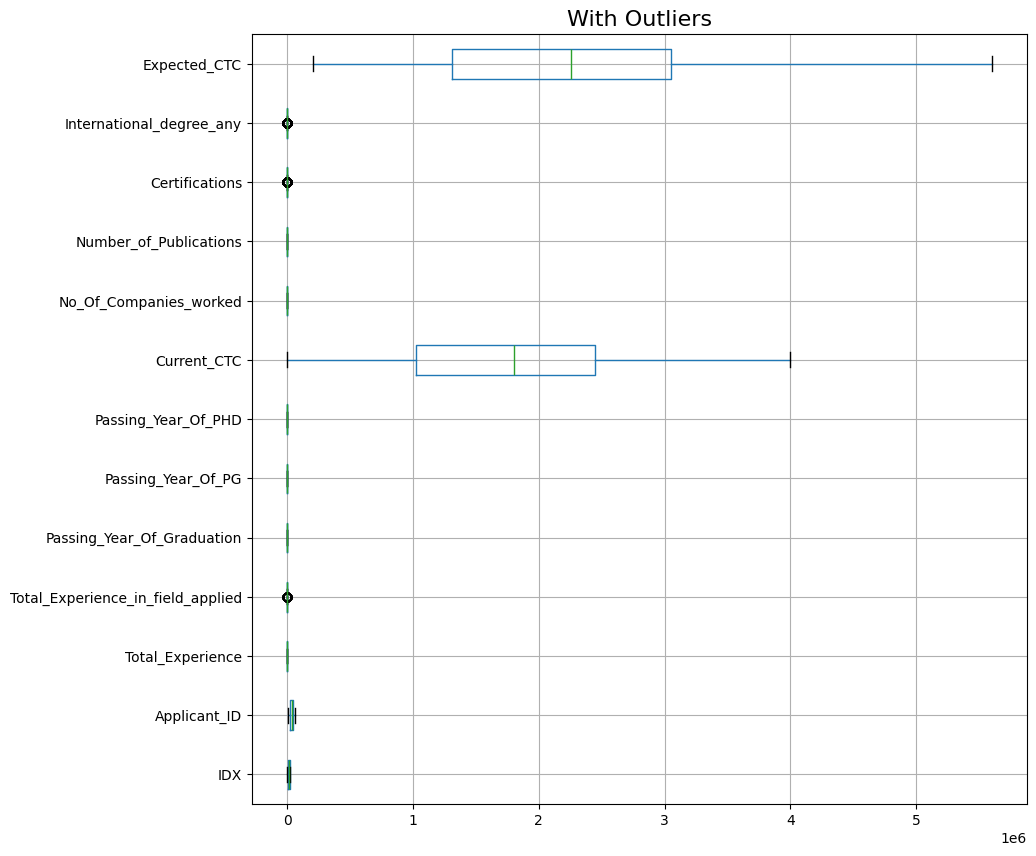

In [11]:
#checking outliers
cont = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 10))
df[cont].boxplot(vert=False)
plt.title('With Outliers', fontsize=16)
plt.show()

In [12]:
#fixing outliers
def remove_outlier(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lr = q1 - (1.5 * iqr)
    ur = q3 + (1.5 * iqr)
    return lr, ur

for column in df[cont].columns:
    lr, ur = remove_outlier(df[column])
    df[column] = np.where(df[column] > ur, ur, df[column])
    df[column] = np.where(df[column] < lr, lr, df[column])

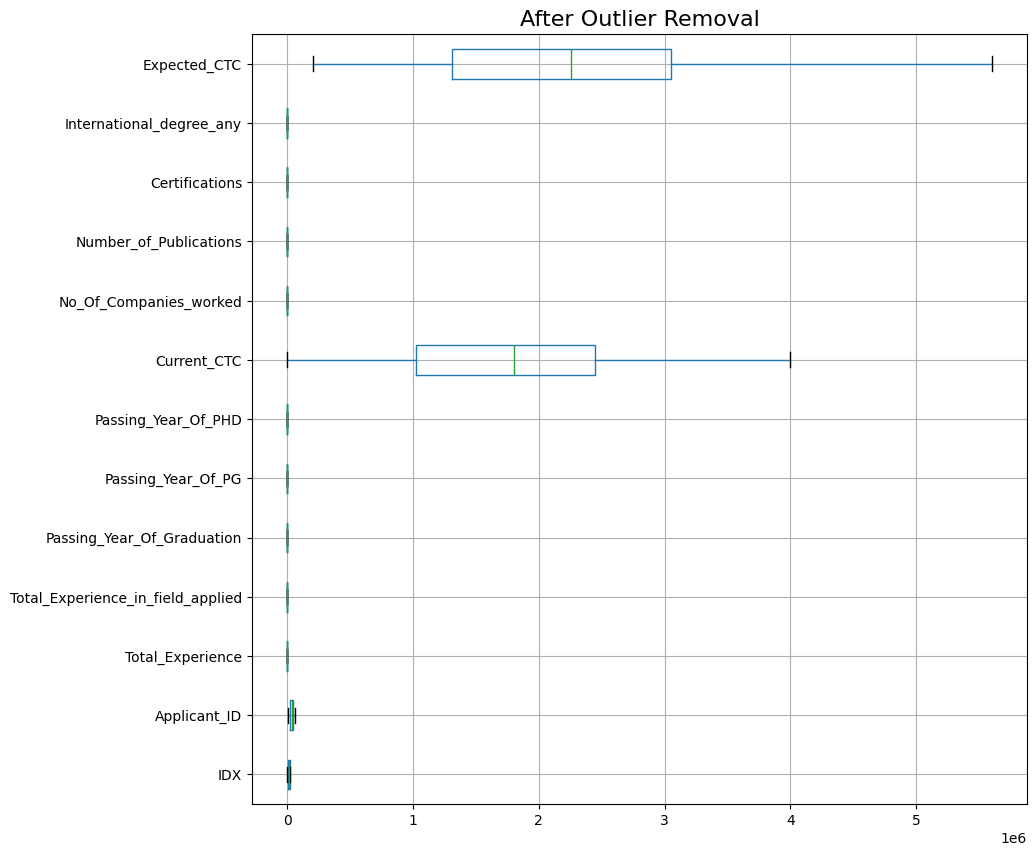

In [13]:
#after removing outliers
plt.figure(figsize=(10, 10))
df[cont].boxplot(vert=False)
plt.title('After Outlier Removal', fontsize=16)
plt.show()

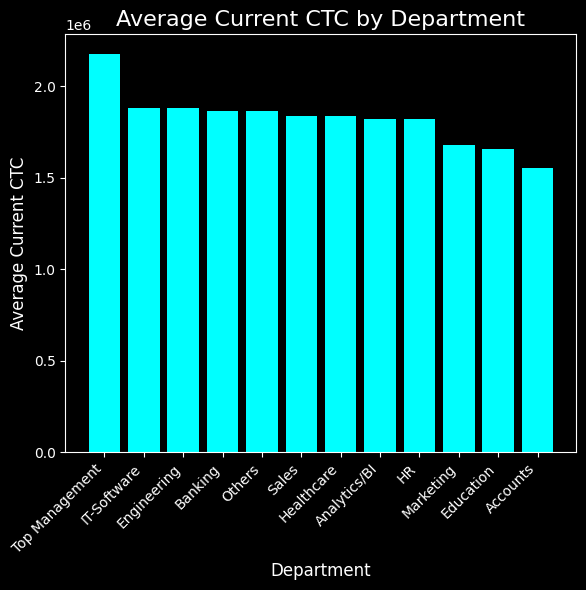

In [14]:
#comparing the department and its salaries
plt.style.use('dark_background')
bar1 = df.groupby("Department")["Current_CTC"].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 6))
plt.bar(bar1.index, bar1.values, color='cyan')
plt.title("Average Current CTC by Department", fontsize=16)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Average Current CTC", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
#3.handling missing data
#fill missing numeric values with mean
for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].fillna(df[col].mean())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes
#filled missing categorical values with numeric values by assigning each unique
# element to a number

In [16]:
""" I am going to use Random Forest method because it has high accuracy, helps to prevent overfitting
    and are relatively robust to outliers
    Salary decisions are often based on complex, non-linear combinations of features

    Random Forest can capture complex, non-linear interactions between these variables without requiring
    manual feature engineering.

    Random Forest can model these interactions automatically because it builds many decision trees that
    capture different splits in the data.

    This results in high generalization accuracy
"""

' I am going to use Random Forest method because it has high accuracy, helps to prevent overfitting\n    and are relatively robust to outliers\n    Salary decisions are often based on complex, non-linear combinations of features\n\n    Random Forest can capture complex, non-linear interactions between these variables without requiring\n    manual feature engineering.\n\n    Random Forest can model these interactions automatically because it builds many decision trees that\n    capture different splits in the data.\n\n    This results in high generalization accuracy\n'

In [17]:
#4.Training and testing
X = df.drop(columns=['Expected_CTC'])
Y = df['Expected_CTC']
#classifying the 75% of the dataset to training set and rest 25% for test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
Y_pred = rf.predict(X_test)

In [18]:
mae = metrics.mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print(f"Random Forest MAE:  {mae:,.2f}")
print(f"Random Forest RMSE: {rmse:,.2f}")

Random Forest MAE:  14,161.30
Random Forest RMSE: 26,316.72


In [19]:
meanexpctc = df['Expected_CTC'].mean()
print(meanexpctc)

2250154.5104


In [20]:
#5.Evaluation
#comparing rmse and expectedctc
percentage = (rmse / meanexpctc) * 100
print(percentage)

1.1695514886058287


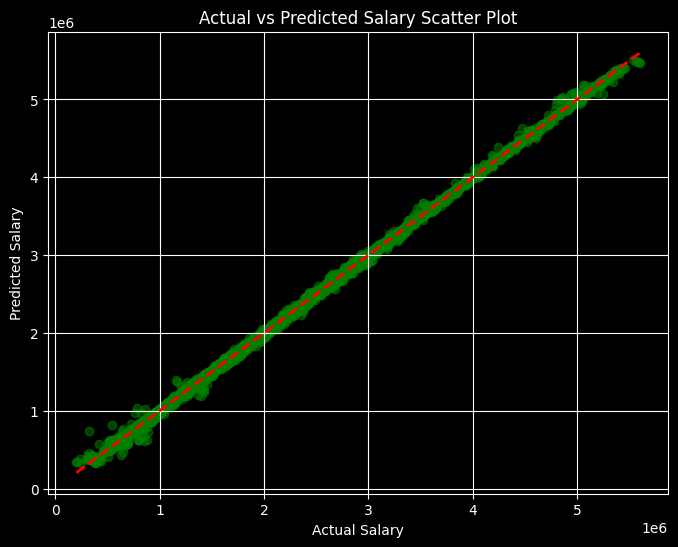

In [21]:
#comparing the predictions and testing data
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
#constructed a red line for the actual salaries
#this scatter plot explains actual salaries and the predicted salaries.
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary Scatter Plot')
plt.grid(True)
plt.show()

In [22]:
print(
    f"Summary — RMSE: {rmse:,.2f}, Mean Expected_CTC: {meanexpctc:,.2f}, Relative error: {percentage:.2f}%"
)
print(
    "The goal of this project was to develop a machine learning model that predicts the salary "
    "to be offered to a candidate based on their profile, using historical data. "
    "This approach aims to reduce manual judgment and ensure fairness by providing consistent "
    "salary offers for employees with similar profiles. "
    "By using the Random Forest regression algorithm, the model achieved an exceptionally low "
    "error rate, meaning its predicted salaries are very close to the actual salaries."
)

Summary — RMSE: 26,316.72, Mean Expected_CTC: 2,250,154.51, Relative error: 1.17%
The goal of this project was to develop a machine learning model that predicts the salary to be offered to a candidate based on their profile, using historical data. This approach aims to reduce manual judgment and ensure fairness by providing consistent salary offers for employees with similar profiles. By using the Random Forest regression algorithm, the model achieved an exceptionally low error rate, meaning its predicted salaries are very close to the actual salaries.
